In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist
from sklearn.metrics import pairwise_distances
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [64]:
# Load data
df = pd.read_csv("../Data/final_cleaned_dataset.csv", index_col=0)

# Separate country info
country_info = df[['CountryCode', 'CountryName']]
df_features = df.drop(columns=['CountryCode', 'CountryName'])
print("Colums:", df_features.columns.tolist())

Colums: ['TourismEmploymentPer1000', 'TourismGDPPercentage', 'BusinessToPersonalRatio', 'AverageStayDays', 'InboundArrivalsPer1000', 'DomesticTouristsPer1000', 'InboundToOutboundRatio', 'GroceriesCostIndex', 'RestaurantPriceIndex', 'SafetyIndex', 'HealthCareIndex', 'ClimateIndex', 'ReverseTrafficIndex', 'ReversePollutionIndex']


In [66]:
#Find best number of clusters using silhouette scores and elbow method
range_n_clusters = range(2, 11) #between 2 and 11 clusters
inertia = []
silhouette_scores = []

In [68]:
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(df_features)
    silhouette_avg = silhouette_score(df_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertia.append(kmeans.inertia_)
    print(f"Number of clusters: {n_clusters}, Silhouette score: {silhouette_avg:.3f}, Inertia: {kmeans.inertia_:.3f}")

Number of clusters: 2, Silhouette score: 0.222, Inertia: 969.250
Number of clusters: 3, Silhouette score: 0.231, Inertia: 823.032
Number of clusters: 4, Silhouette score: 0.164, Inertia: 787.218
Number of clusters: 5, Silhouette score: 0.155, Inertia: 703.889
Number of clusters: 6, Silhouette score: 0.150, Inertia: 663.728
Number of clusters: 7, Silhouette score: 0.139, Inertia: 617.418
Number of clusters: 8, Silhouette score: 0.123, Inertia: 559.005
Number of clusters: 9, Silhouette score: 0.111, Inertia: 547.965
Number of clusters: 10, Silhouette score: 0.121, Inertia: 515.205


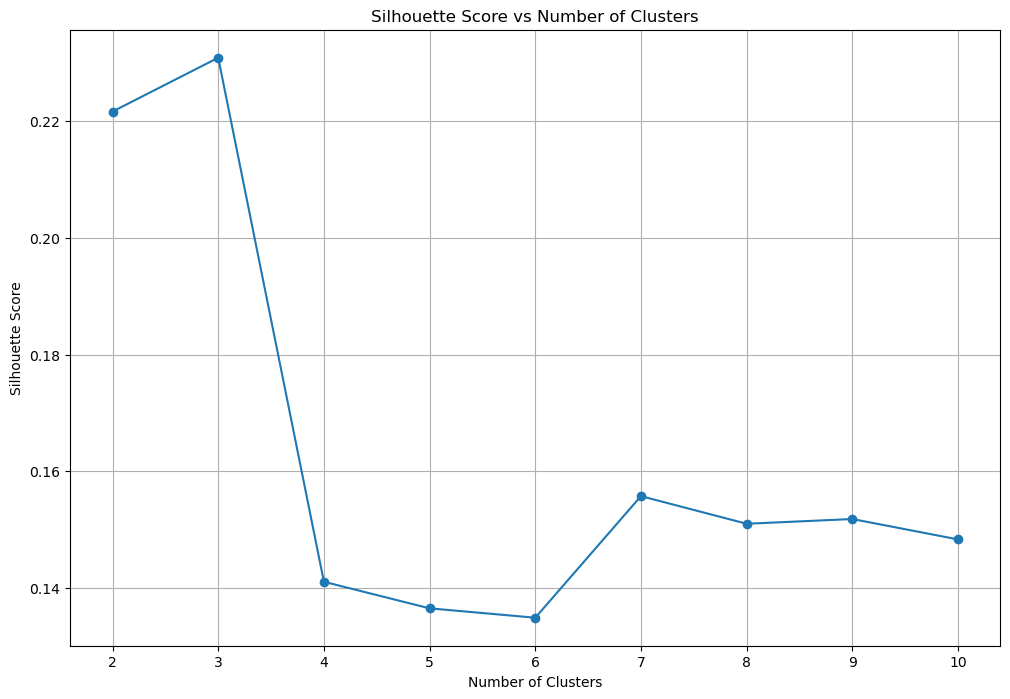

In [226]:
# Plot silhouette scores
plt.figure(figsize=(12, 8))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

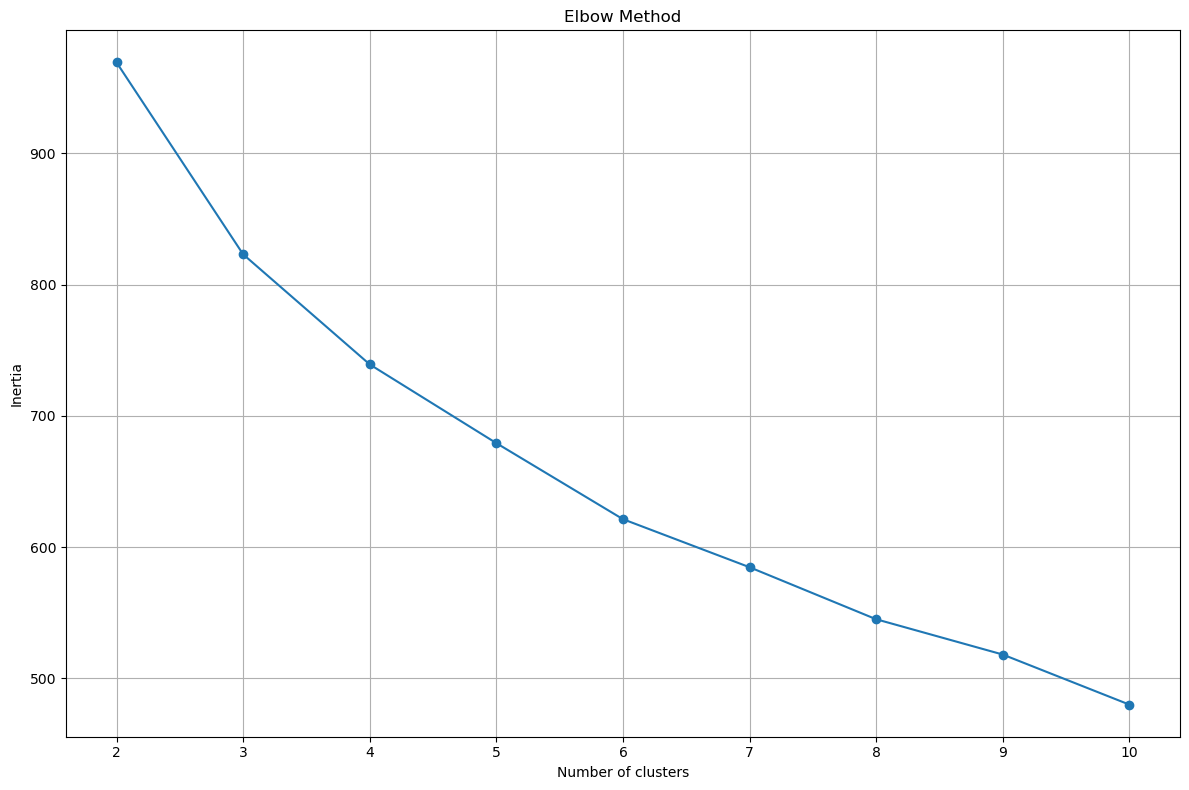

In [228]:
plt.figure(figsize=(12, 8))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.grid(True)
plt.show()

In [230]:
#Choose the best k (based on max silhouette score)
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
best_k_elbow = range_n_clusters[inertia.index(max(inertia))]
print(f"Best number of clusters based on Silhouette scores: {best_k}")
print(f"Best number of clusters based on Elbow method: {best_k_elbow}")

Best number of clusters based on Silhouette scores: 3
Best number of clusters based on Elbow method: 2


The best number of clusters, according to Silhouette scores, is 3. Moreover, the plot for Elbow method shows k=3 determines a difference in terms of inertia.

In [233]:
N= len(df_features.columns)

In [235]:
#Apply KMeans with best_k

def runKMeans(data, best_k):
    if (best_k==0):
          kmeans_final = KMeans(random_state=43, n_init=10, max_iter=1000)
    else:
        kmeans_final = KMeans(n_clusters=best_k,random_state=43, n_init=10, max_iter=1000)
    cluster_labels = kmeans_final.fit_predict(data)
    return cluster_labels

In [237]:
cluster_labels = runKMeans(df_features, best_k)

In [239]:
def printClustersAndCountries(country_info, cluster_labels):
    # Create final dataframe with cluster assignments
    df_clustered = country_info.copy()
    df_clustered["Cluster"] = cluster_labels
    df_clustered_final = pd.concat([country_info, pd.Series(cluster_labels, name="Cluster")], axis=1)

    # Show clusters and countries
    cluster_counts = df_clustered_final['Cluster'].value_counts()
    print("Number of countries in each cluster:")
    print(cluster_counts)
 
    #Group countries by cluster and display all
    k_grouped = df_clustered_final.groupby('Cluster')['CountryName'].apply(list).reset_index()
    k_grouped.columns = ['Cluster', 'Countries']
    print("\nCountries grouped by cluster:")
    for _, row in k_grouped.iterrows():
        print(f"\nCluster {row['Cluster']} - {len(row['Countries'])} countries:")
        print(', '.join(row['Countries']))



In [241]:
printClustersAndCountries(country_info, cluster_labels)

Number of countries in each cluster:
Cluster
0    55
1    31
2     3
Name: count, dtype: int64

Countries grouped by cluster:

Cluster 0 - 55 countries:
Albania, Algeria, Angola, Argentina, Azerbaijan, Bahrain, Belarus, Belize, Brazil, Cameroon, Chile, Costa Rica, Dominican Republic, Ecuador, Egypt, El Salvador, Georgia, Ghana, Greece, Honduras, Hungary, India, Indonesia, Jordan, Kazakhstan, Kyrgyzstan, Lebanon, Madagascar, Malaysia, Mauritius, Mexico, Moldova, Mongolia, Morocco, Mozambique, Namibia, Nicaragua, Nigeria, Palestine, Panama, Paraguay, Philippines, Poland, Puerto Rico, Romania, Russia, Saudi Arabia, Serbia, South Africa, Sri Lanka, Thailand, Turkey, Uganda, Uzbekistan, Zambia

Cluster 1 - 31 countries:
Australia, Austria, Belgium, Brunei, Cayman Islands, Cyprus, Denmark, Estonia, Finland, France, Germany, Iceland, Israel, Japan, Latvia, Lithuania, Netherlands, New Zealand, Norway, Portugal, Slovakia, Slovenia, South Korea, Spain, Sweden, Switzerland, Taiwan, United Arab Em

In [243]:
# Apply t-SNE for 2D projection
def applyTSNE(data, cluster_labels, df):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(data)
    plt.figure(figsize=(14, 12))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='viridis', s=50)
    plt.title('t-SNE Visualization of Clusters')
    plt.xlabel('TSNE-1')
    plt.ylabel('TSNE-2')
    plt.colorbar(label='Cluster')

    # Add country names as labels
    for i, country in enumerate(df["CountryName"]):
        plt.text(X_tsne[i, 0], X_tsne[i, 1], country, fontsize=8)
    plt.grid(True)
    plt.show()


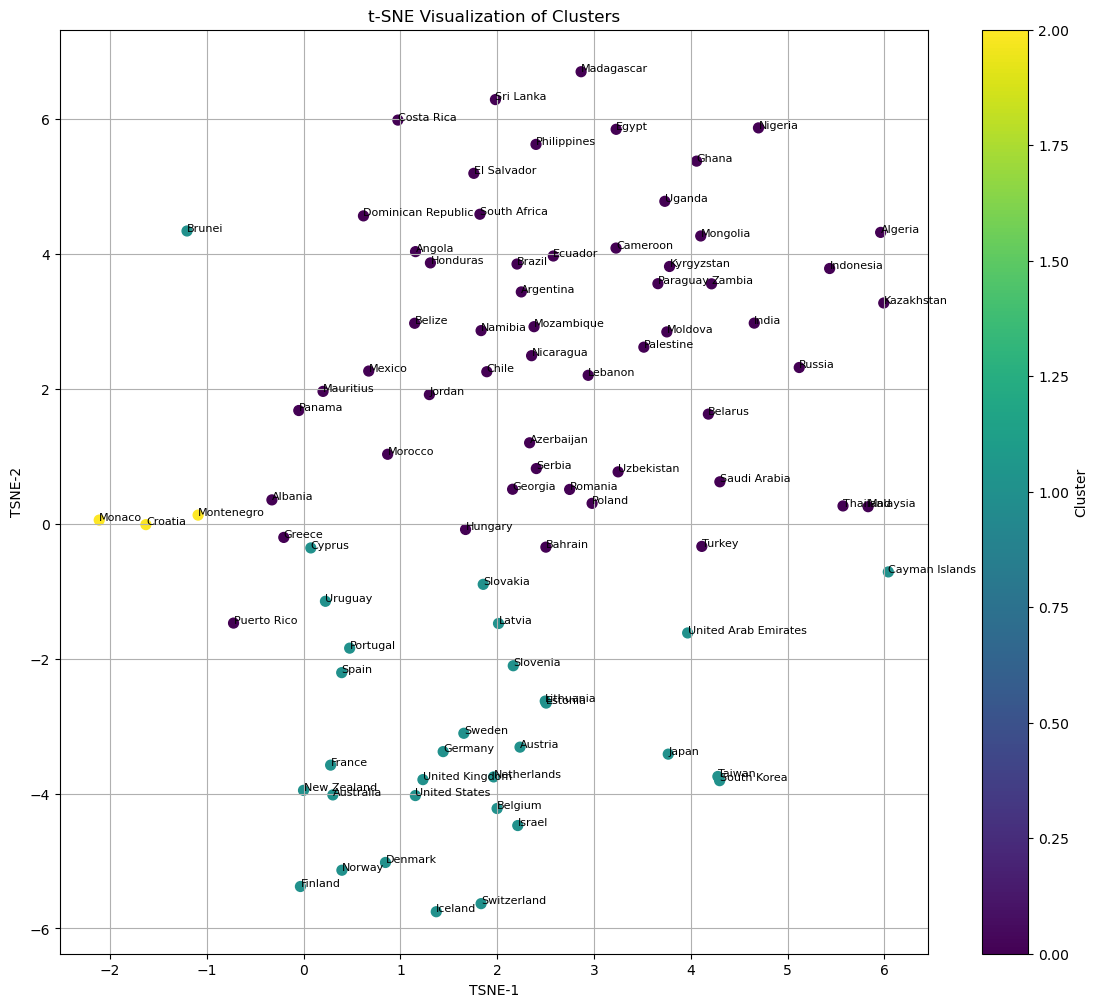

In [245]:
applyTSNE(df_features, cluster_labels, df)

Cluster 0 (Navy):

* Countries in this group are likely more similar to each other.
* Might include emerging economies, poor countries with low cost of living

Cluster 1 (Dark Green):

* More scattered and spread out.
* Indicates higher internal variation between countries in this cluster.
* This could represent more developed economies (e.g., high infrastructure, better scores in safety, healthcare, tourism).
  
Cluster 2(Yellow):

* It seems to contain some outliers (e.g., Monaco)

In [248]:
#Cluster Evaluation
def dunn_index(X, labels):
    unique_cluster_labels = np.unique(labels)
    n_clusters = len(unique_cluster_labels)
    # Compute intra-cluster distances (max within each cluster)
    intra_dists = []
    for k in unique_cluster_labels:
        cluster_points = X[labels == k]
        if len(cluster_points) > 1:
            distances = pairwise_distances(cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)
 
    max_intra = np.max(intra_dists)
 
    # Compute inter-cluster distances (min between each pair of clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_cluster_labels[i]]
            cluster_j = X[labels == unique_cluster_labels[j]]
            distances = pairwise_distances(cluster_i, cluster_j)
            inter_dists.append(np.min(distances))
 
    min_inter = np.min(inter_dists)
 
    return min_inter / max_intra if max_intra != 0 else 0
 

In [250]:
def computeEvaluationMeasures(data, cluster_labels):
    silhouette = silhouette_score(data, cluster_labels)
    dunn = dunn_index(data, cluster_labels)
    davies = davies_bouldin_score(data, cluster_labels)
    calinski = calinski_harabasz_score(data, cluster_labels)
    return silhouette, dunn, davies, calinski


In [252]:
silhouette, dunn, davies, calinski = computeEvaluationMeasures(df_features, cluster_labels)
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Dunn Index: {dunn:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.2332
Dunn Index: 0.1784
Davies-Bouldin Index: 1.3360
Calinski-Harabasz Index: 22.1096


Interpretation of evaluation measures:

* Silhouette Score: moderate clustering quality. Some points may be hard to assign confidently.
* Dunn Index: Very low. This suggests clusters are not well separated or some are too spread out.
* Davies-Bouldin Index: Acceptable but not great. Lower is better, and anything above 1.0 shows clusters are not well isolated. The clustering is average, with room to improve separation.
* Calinski-Harabasz Index: Modest separation. Higher values (100+) typically indicate very distinct clusters. This value is okay but not strong.

In [255]:
# Add labels back to data
clustered_df = pd.concat([country_info, pd.DataFrame(df_features), pd.Series(cluster_labels, name='Cluster')], axis=1)
clustered_df.to_csv('kmeans_3_clusters.csv')

# Run kMeans for 8 clusters (default value in the kMeans library)

In [258]:
cluster_labels = runKMeans(df_features, 0)
printClustersAndCountries(country_info, cluster_labels)

Number of countries in each cluster:
Cluster
2    29
1    19
3    13
6    12
5     8
7     4
0     3
4     1
Name: count, dtype: int64

Countries grouped by cluster:

Cluster 0 - 3 countries:
Cayman Islands, Malaysia, Thailand

Cluster 1 - 19 countries:
Albania, Bahrain, Croatia, Cyprus, Greece, Hungary, Latvia, Mauritius, Mexico, Montenegro, Panama, Portugal, Puerto Rico, Slovakia, Slovenia, Spain, Turkey, United Arab Emirates, Uruguay

Cluster 2 - 29 countries:
Angola, Argentina, Azerbaijan, Belarus, Belize, Brazil, Cameroon, Chile, Ecuador, Georgia, India, Jordan, Kyrgyzstan, Lebanon, Moldova, Mongolia, Morocco, Mozambique, Namibia, Nicaragua, Palestine, Paraguay, Poland, Romania, Russia, Saudi Arabia, Serbia, Uzbekistan, Zambia

Cluster 3 - 13 countries:
Australia, Belgium, France, Germany, Israel, Japan, Lithuania, New Zealand, South Korea, Sweden, Taiwan, United Kingdom, United States

Cluster 4 - 1 countries:
Monaco

Cluster 5 - 8 countries:
Austria, Denmark, Estonia, Finland, I

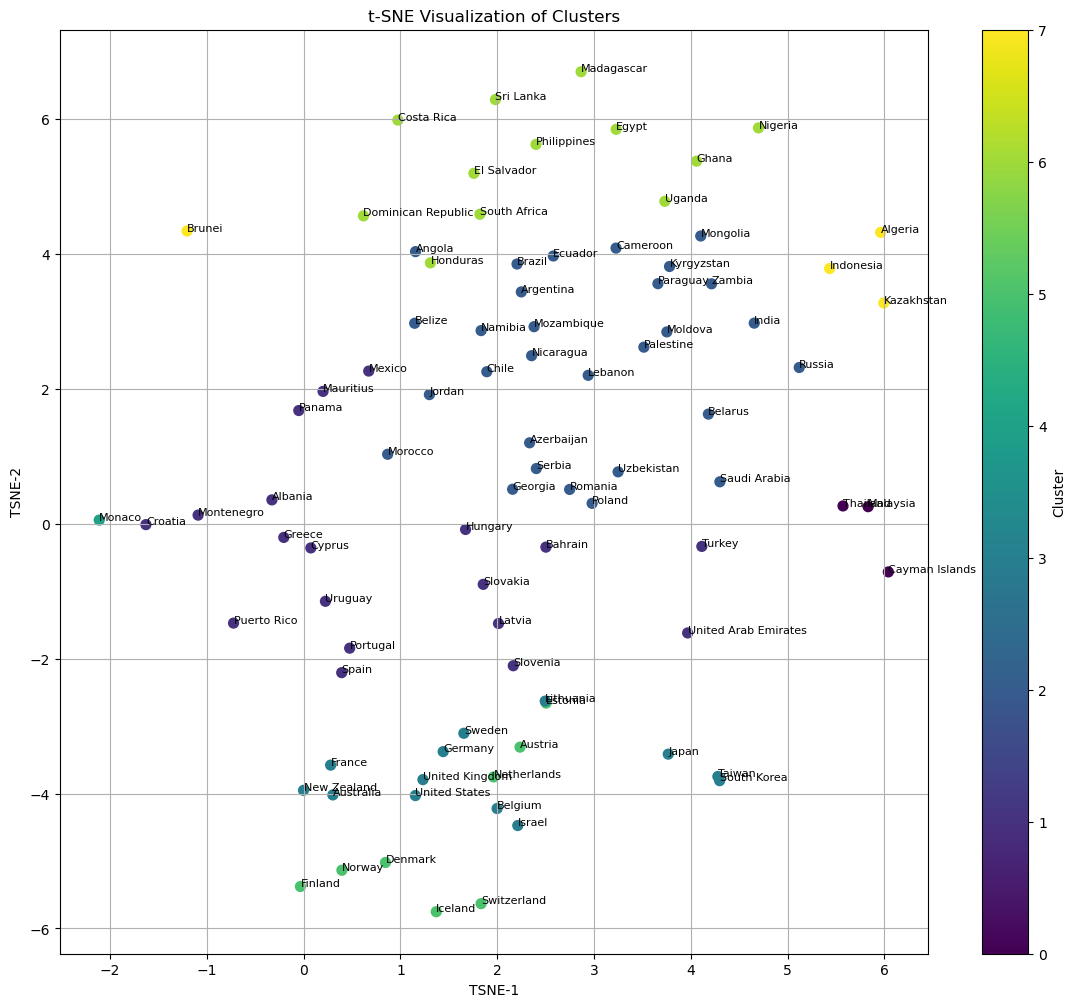

In [196]:
applyTSNE(df_features, cluster_labels, df)

In [260]:
silhouette, dunn, davies, calinski = computeEvaluationMeasures(df_features, cluster_labels)
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Dunn Index: {dunn:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.1465
Dunn Index: 0.2163
Davies-Bouldin Index: 1.4153
Calinski-Harabasz Index: 15.0912


In [262]:
# Add labels back to data
clustered_df = pd.concat([country_info, pd.DataFrame(df_features), pd.Series(cluster_labels, name='Cluster')], axis=1)
clustered_df.to_csv('kmeans_8_clusters.csv')

# K-MEANS (selected the features based on correlation matrix)

In [271]:
# Compute correlation matrix
correlation_matrix = df_features.corr(method='spearman')
  
# Identify features with correlation above a threshold (e.g., 0.85)
threshold = 0.6
to_remove = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            colname = correlation_matrix.columns[i]
            to_remove.add(colname)
 
# Print final feature list
features_to_use = [col for col in df_features.columns if col not in to_remove]
print("Features to use for KMeans clustering (after removing highly correlated ones):")
for feature in features_to_use:
    print("-", feature)

Features to use for KMeans clustering (after removing highly correlated ones):
- TourismEmploymentPer1000
- TourismGDPPercentage
- BusinessToPersonalRatio
- AverageStayDays
- InboundArrivalsPer1000
- DomesticTouristsPer1000
- InboundToOutboundRatio
- SafetyIndex
- ClimateIndex


Best number of clusters based on Silhouette scores: 3
Best number of clusters based on Elbow method: 2


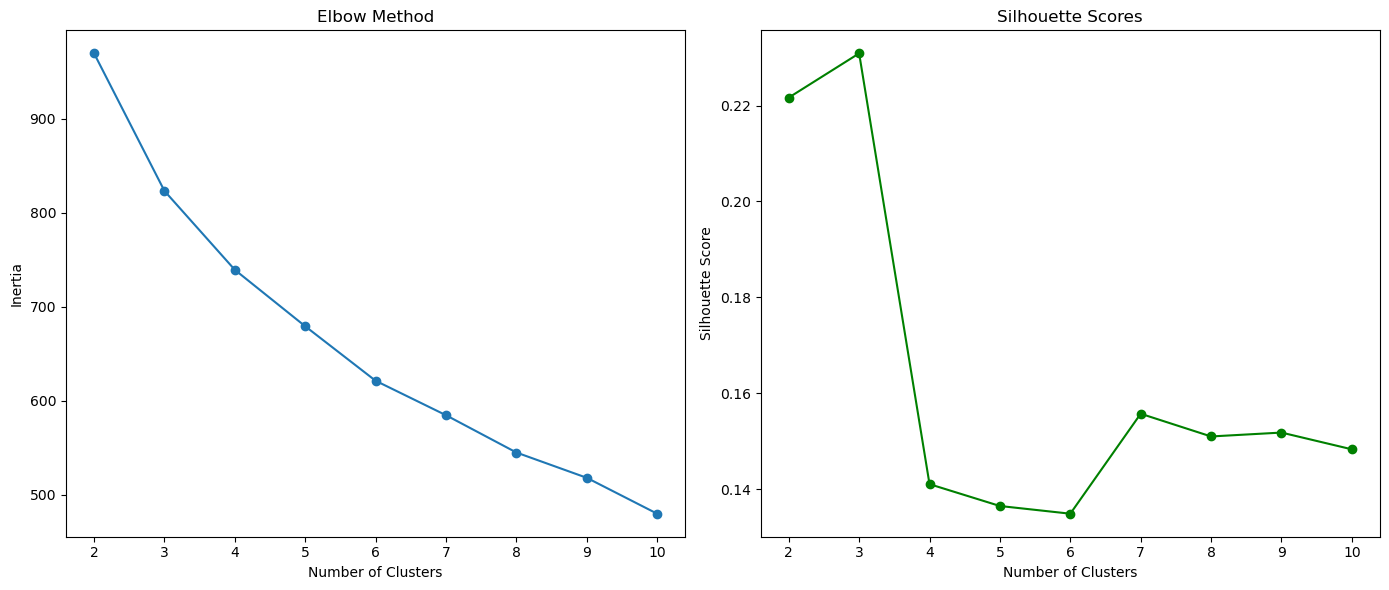

In [273]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)
 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_features, kmeans.labels_))
 
#Choose the best k (based on max silhouette score)
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
best_k_elbow = range_n_clusters[inertia.index(max(inertia))]
print(f"Best number of clusters based on Silhouette scores: {best_k}")
print(f"Best number of clusters based on Elbow method: {best_k_elbow}")
 
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
 
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
 
plt.tight_layout()
plt.show()